# 대출 승인 예측 — 전처리 · 모델 학습 · 비교 분석

**데이터**: training_data.csv (5,000건 × 13개 변수)  
**모델**: Logistic Regression vs Random Forest  
**평가**: Accuracy · Precision · Recall · F1 · ROC-AUC

---
## 목차
1. 환경 설정  
2. 전처리 — 결측치 / 인코딩 / 스케일링 판단  
3. 데이터 분리 (Train / Test)  
4. 클래스 불균형 처리 (SMOTE vs class_weight)  
5. 모델 학습 — Logistic Regression  
6. 모델 학습 — Random Forest  
7. 성능 평가 및 비교  
8. 특성 중요도 분석  
9. 최종 결론 및 모델 선택 근거

In [11]:
!pip install -Uq koreanize-matplotlib
import koreanize_matplotlib

%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 32.2 MB/s eta 0:00:00


## 1. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing      import StandardScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
from imblearn.over_sampling     import SMOTE
from imblearn.pipeline          import Pipeline as ImbPipeline

# ── 시각화 설정 ───────────────────────────────────────────────
plt.rcParams['font.family']        = 'Malgun Gothic'   # Windows
# plt.rcParams['font.family']     = 'AppleGothic'      # macOS
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 120
sns.set_style('whitegrid')

RANDOM_STATE = 42
TARGET       = '승인여부'
PALETTE      = {'LR': '#4B8BE0', 'RF': '#E05C4B'}

print('✅ 라이브러리 로드 완료')
print('   imbalanced-learn 미설치 시: pip install imbalanced-learn')

✅ 라이브러리 로드 완료
   imbalanced-learn 미설치 시: pip install imbalanced-learn


## 2. 전처리

EDA 결과를 토대로 세 가지 전처리 결정을 내린다.

### 2-1. 결측치 처리

**EDA 결과**: 13개 변수 모두 결측치 0건  
**결론**: 별도 처리 불필요

> 만약 결측치가 발생할 경우의 전략:
> - 수치형 변수 → 중앙값(median) 대체 (이상치에 강건)
> - 점수형 변수 → 최빈값(mode) 대체 (카테고리 성격)
> - 결측 비율 > 30% → 변수 제거 또는 결측 여부를 별도 이진 변수로 추가

In [2]:
df = pd.read_csv('training_data.csv')

missing_total = df.isnull().sum().sum()
print(f'전체 결측치 건수: {missing_total}건')

if missing_total > 0:
    num_cols   = ['나이', '연봉', '재산', '예금', '자동차배기량', '자녀수', '신청금액', '신청기간월']
    score_cols = ['학력점수', '결혼점수', '회사규모점수', '대출분류점수']
    # 중앙값 대체 (수치형)
    df[num_cols]   = df[num_cols].fillna(df[num_cols].median())
    # 최빈값 대체 (점수형)
    df[score_cols] = df[score_cols].fillna(df[score_cols].mode().iloc[0])
    print('→ 결측치 대체 완료')
else:
    print('✅ 결측치 없음 — 처리 불필요')

전체 결측치 건수: 0건
✅ 결측치 없음 — 처리 불필요


### 2-2. 범주형 변수 인코딩 판단

**이 데이터의 모든 변수는 숫자형(int64)** 이므로 추가 인코딩은 불필요하다.  
단, 점수형 변수(학력점수 등)는 순서 정보가 있는 **순서형(Ordinal)** 이므로  
이미 숫자로 표현된 현재 형태가 가장 적절하다.

| 인코딩 방법 | 적용 기준 | 이 데이터 |
|-------------|-----------|----------|
| **Label Encoding** | 순서 있는 범주형 (저/중/고) | 점수형 변수 → 이미 숫자 ✅ |
| **One-Hot Encoding** | 순서 없는 범주형 (성별, 지역) | 해당 없음 |
| **그대로 유지** | 연속형 수치 | 수치형 변수 ✅ |

> **자동차배기량** (0, 1000, 1600, 2000, 2500, 3000, 3500)은 수치형 연속 변수로 처리한다.  
> 0값은 "차량 없음"을 의미하므로 별도 이진 변수 추가를 고려할 수 있다.

In [3]:
# ── 파생 변수 생성 (선택적 피처 엔지니어링) ─────────────────────
# 연봉 대비 신청금액 비율 → 상환 능력을 직접 나타내는 지표
df['연봉대비신청비율'] = df['신청금액'] / df['연봉']

# 재산 대비 신청금액 비율 → 담보 여력 지표
df['재산대비신청비율'] = df['신청금액'] / df['재산']

# 차량 보유 여부 (0 → 무, 1 → 유)
df['차량보유'] = (df['자동차배기량'] > 0).astype(int)

print('파생 변수 추가 후 shape:', df.shape)
df[['연봉대비신청비율', '재산대비신청비율', '차량보유']].describe()

파생 변수 추가 후 shape: (5000, 16)


,연봉대비신청비율,재산대비신청비율,차량보유
count,5000.000000,5000.000000,5000.000000
mean,1.606761,2.166602,0.694200
std,1.429189,40.966686,0.460792
min,0.039294,0.011514,0.000000
25%,0.651770,0.219368,0.000000
50%,1.218726,0.413573,1.000000
75%,2.030591,0.820349,1.000000
max,9.919391,2734.583628,1.000000


### 2-3. 스케일링 필요 여부 판단

| 모델 | 스케일링 필요? | 이유 |
|------|--------------|------|
| **Logistic Regression** | ✅ 필수 | 경사하강법 기반, 변수 단위 차이가 수렴 속도와 계수에 영향 |
| **Random Forest** | ❌ 불필요 | 분기 기준이 상대적 순서만 사용, 스케일 무관 |

**이 데이터의 스케일 차이 예시**:
- 연봉: ~8천만 (단위: 원)
- 나이: ~43
- 자녀수: ~1.3

→ 범위가 크게 달라 LR에서 스케일링 없이 학습하면 연봉의 계수가 지나치게 작아진다.

In [4]:
# ── 피처 / 타겟 분리 ─────────────────────────────────────────
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

print(f'피처 수: {len(FEATURES)}개')
print('피처 목록:', FEATURES)

피처 수: 15개
피처 목록: ['나이', '연봉', '재산', '예금', '자동차배기량', '자녀수', '신청금액', '신청기간월', '학력점수', '결혼점수', '회사규모점수', '대출분류점수', '연봉대비신청비율', '재산대비신청비율', '차량보유']


## 3. 데이터 분리 (Train / Test)

**왜 Stratified Split을 쓰는가?**  
일반 split은 분할 시 클래스 비율이 달라질 수 있다.  
`stratify=y`를 지정하면 학습/테스트 셋 모두 원본과 동일한 71:29 비율을 유지한다.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,          # 80% 학습 / 20% 테스트
    random_state = RANDOM_STATE,
    stratify     = y             # ← 클래스 비율 유지
)

print(f'학습 데이터: {X_train.shape[0]:,}건')
print(f'테스트 데이터: {X_test.shape[0]:,}건')
print()
print('[클래스 비율 확인]')
for name, y_part in [('원본', y), ('학습', y_train), ('테스트', y_test)]:
    ratio = y_part.value_counts(normalize=True)
    print(f'  {name:4s} → 승인: {ratio[1]:.1%} / 거절: {ratio[0]:.1%}')

학습 데이터: 4,000건
테스트 데이터: 1,000건

[클래스 비율 확인]
  원본   → 승인: 71.2% / 거절: 28.8%
  학습   → 승인: 71.2% / 거절: 28.8%
  테스트  → 승인: 71.2% / 거절: 28.8%


## 4. 클래스 불균형 처리

**EDA 결과**: 승인 71.2% / 거절 28.8% → **불균형 비율 약 2.5:1**

두 가지 방법을 모두 구현하고 비교한다.

| 방법 | 원리 | 장점 | 단점 |
|------|------|------|------|
| **SMOTE** | 소수 클래스를 KNN 보간으로 합성 | 데이터 자체를 균형화 | 합성 데이터가 실제와 다를 수 있음 |
| **class_weight** | 소수 클래스에 높은 가중치 | 원본 데이터 유지 | 일부 알고리즘에서만 지원 |

> **이 데이터의 경우**: 비율 2.5:1은 심각하지 않으므로 두 방법 모두 효과적이다.  
> 주 전략: `class_weight='balanced'` (간단·안정적) + SMOTE 비교 실험

In [6]:
# ── SMOTE 적용 (학습 데이터에만) ──────────────────────────────
# 중요: 테스트 데이터에는 절대 SMOTE를 적용하지 않는다.
# 이유: 테스트는 실제 배포 환경을 시뮬레이션해야 하므로 원본 분포를 유지해야 한다.

smote = SMOTE(
    random_state  = RANDOM_STATE,
    k_neighbors   = 5,     # 합성 시 참조할 이웃 수 (기본값)
    sampling_strategy = 'minority'  # 소수 클래스만 오버샘플링
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('[SMOTE 적용 결과]')
print(f'  적용 전: {len(y_train):,}건  (승인 {y_train.sum():,} / 거절 {(y_train==0).sum():,})')
print(f'  적용 후: {len(y_train_sm):,}건  (승인 {y_train_sm.sum():,} / 거절 {(y_train_sm==0).sum():,})')
print(f'  증가 건수: +{len(y_train_sm) - len(y_train):,}건 (소수 클래스 합성)')

[SMOTE 적용 결과]
  적용 전: 4,000건  (승인 2,847 / 거절 1,153)
  적용 후: 5,694건  (승인 2,847 / 거절 2,847)
  증가 건수: +1,694건 (소수 클래스 합성)


In [7]:
# ── 스케일링 (LR용 전용 데이터셋 준비) ───────────────────────
# StandardScaler: 평균 0, 표준편차 1로 변환
# fit은 학습 데이터에만 → test에는 transform만 적용 (데이터 누수 방지)

scaler = StandardScaler()

# 원본 (class_weight용)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)       # ← fit 금지, transform만

# SMOTE 적용본 (SMOTE + 스케일링)
scaler_sm  = StandardScaler()
X_train_sm_sc = scaler_sm.fit_transform(X_train_sm)

print('✅ 스케일링 완료')
print(f'   X_train_sc  shape: {X_train_sc.shape}  (LR + class_weight용)')
print(f'   X_train_sm_sc shape: {X_train_sm_sc.shape}  (LR + SMOTE용)')
print()
print('💡 Random Forest는 스케일링 불필요 — 원본 X_train/X_test 사용')

✅ 스케일링 완료
   X_train_sc  shape: (4000, 15)  (LR + class_weight용)
   X_train_sm_sc shape: (5694, 15)  (LR + SMOTE용)

💡 Random Forest는 스케일링 불필요 — 원본 X_train/X_test 사용


## 5. 모델 학습 — Logistic Regression

**특징**: 선형 결정 경계, 빠른 학습, 계수 해석 가능  
**한계**: 비선형 관계 포착 불가, 피처 스케일링 필수  

두 가지 불균형 처리 방법을 각각 학습해 비교한다.
- `LR_cw`: class_weight='balanced'
- `LR_smote`: SMOTE 적용 후 학습

In [8]:
# ── LR 모델 A: class_weight='balanced' ──────────────────────
lr_cw = LogisticRegression(
    C             = 1.0,           # 규제 강도 역수 (클수록 규제 약함)
    class_weight  = 'balanced',    # 소수 클래스에 가중치 자동 부여
    solver        = 'lbfgs',       # 다변수 최적화에 안정적
    max_iter      = 1000,          # 수렴 보장을 위해 충분히 설정
    random_state  = RANDOM_STATE
)
lr_cw.fit(X_train_sc, y_train)
print('LR (class_weight) 학습 완료')

# ── LR 모델 B: SMOTE 적용 ────────────────────────────────────
lr_smote = LogisticRegression(
    C            = 1.0,
    solver       = 'lbfgs',
    max_iter     = 1000,
    random_state = RANDOM_STATE
)
lr_smote.fit(X_train_sm_sc, y_train_sm)
print('LR (SMOTE)         학습 완료')

LR (class_weight) 학습 완료
LR (SMOTE)         학습 완료


In [9]:
# ── LR 교차검증 (StratifiedKFold 5-fold) ──────────────────────
# 단일 분할의 운에 의존하지 않고 안정적 성능 추정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores_lr = cross_validate(
    LogisticRegression(C=1.0, class_weight='balanced', solver='lbfgs',
                       max_iter=1000, random_state=RANDOM_STATE),
    X_train_sc, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print('[Logistic Regression 5-Fold CV 결과]')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cv_scores_lr[f'test_{metric}']
    print(f'  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

[Logistic Regression 5-Fold CV 결과]
  accuracy    : 0.8717 ± 0.0104
  precision   : 0.9489 ± 0.0090
  recall      : 0.8665 ± 0.0097
  f1          : 0.9058 ± 0.0078
  roc_auc     : 0.9507 ± 0.0104


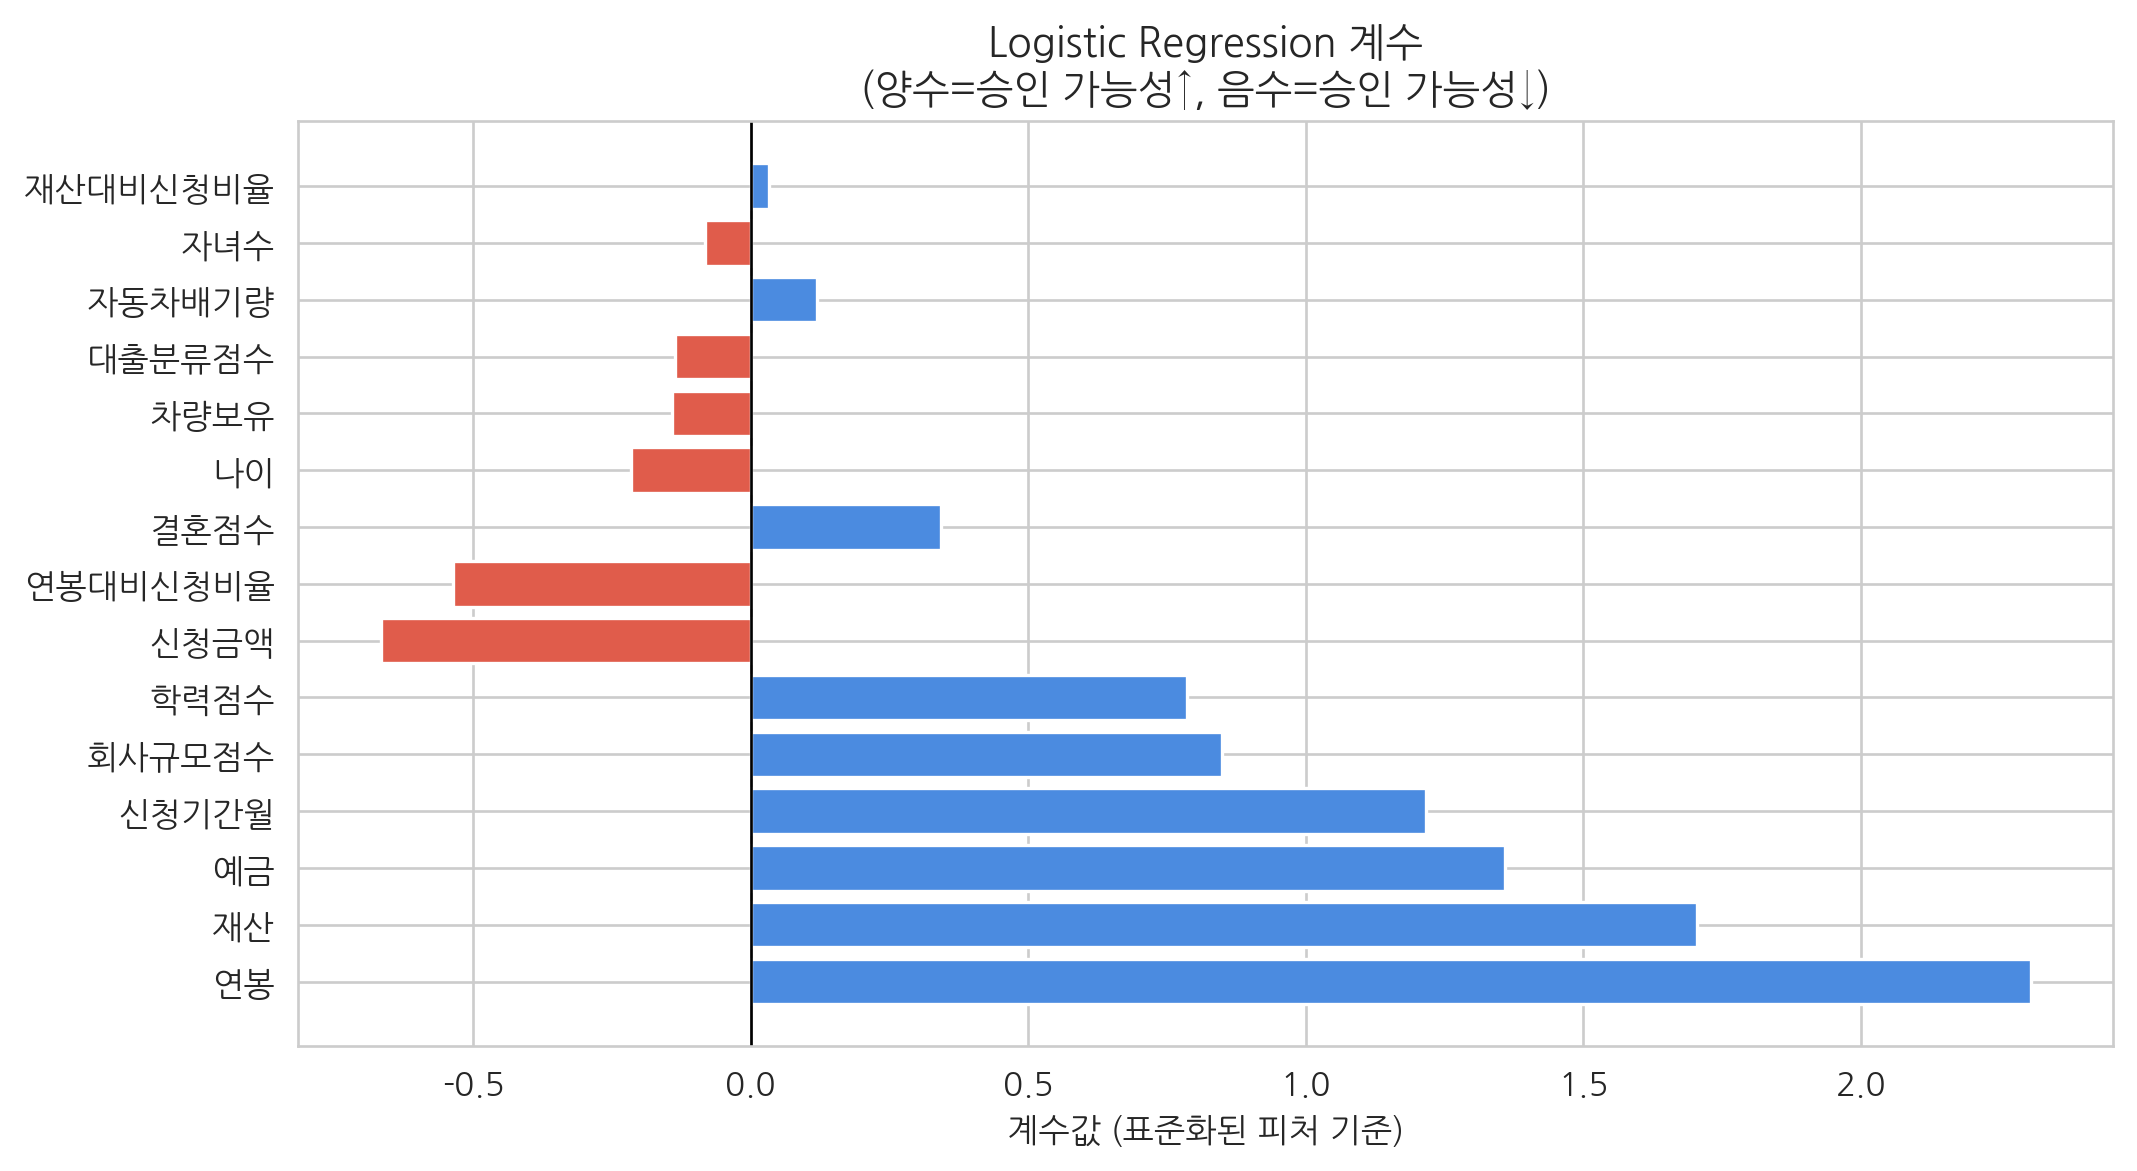


[상위 5개 영향 변수]
    변수       계수
    연봉 2.305622
    재산 1.705636
    예금 1.358664
 신청기간월 1.216032
회사규모점수 0.848948


In [12]:
# ── LR 계수 해석 ─────────────────────────────────────────────
# Logistic Regression의 핵심 장점: 계수를 통해 각 변수의 방향과 크기를 해석 가능
coef_df = pd.DataFrame({
    '변수': FEATURES,
    '계수': lr_cw.coef_[0]
}).sort_values('계수', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E05C4B' if v < 0 else '#4B8BE0' for v in coef_df['계수']]
ax.barh(coef_df['변수'], coef_df['계수'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression 계수\n(양수=승인 가능성↑, 음수=승인 가능성↓)', fontsize=12)
ax.set_xlabel('계수값 (표준화된 피처 기준)')
plt.tight_layout()
plt.show()

print('\n[상위 5개 영향 변수]')
print(coef_df.head().to_string(index=False))

## 6. 모델 학습 — Random Forest

**특징**: 여러 결정 트리의 앙상블, 비선형 관계 포착, 이상치에 강건  
**한계**: 학습 속도 느림, 계수 해석 불가 (블랙박스), 메모리 사용량 큼  
**불균형 처리**: `class_weight='balanced'`를 지원하며, 각 트리에서도 균형 샘플링 가능

In [13]:
# ── RF 모델 A: class_weight='balanced' ──────────────────────
rf_cw = RandomForestClassifier(
    n_estimators  = 300,           # 트리 수 (많을수록 안정, 속도 트레이드오프)
    max_depth     = None,          # 깊이 제한 없음 (학습 후 중요도로 판단)
    min_samples_split = 5,         # 분기를 위한 최소 샘플 수 (과적합 방지)
    min_samples_leaf  = 2,         # 리프 노드 최소 샘플 수
    class_weight  = 'balanced',    # 클래스 불균형 보정
    n_jobs        = -1,            # CPU 전체 코어 사용
    random_state  = RANDOM_STATE
)
rf_cw.fit(X_train, y_train)
print('RF (class_weight) 학습 완료')

# ── RF 모델 B: SMOTE 적용 ────────────────────────────────────
rf_smote = RandomForestClassifier(
    n_estimators  = 300,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    n_jobs        = -1,
    random_state  = RANDOM_STATE
)
rf_smote.fit(X_train_sm, y_train_sm)   # RF는 스케일링 불필요 → X_train_sm 사용
print('RF (SMOTE)         학습 완료')

RF (class_weight) 학습 완료
RF (SMOTE)         학습 완료


In [14]:
# ── RF 교차검증 ───────────────────────────────────────────────
cv_scores_rf = cross_validate(
    RandomForestClassifier(n_estimators=300, class_weight='balanced',
                           min_samples_split=5, min_samples_leaf=2,
                           n_jobs=-1, random_state=RANDOM_STATE),
    X_train, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print('[Random Forest 5-Fold CV 결과]')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cv_scores_rf[f'test_{metric}']
    print(f'  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

[Random Forest 5-Fold CV 결과]
  accuracy    : 0.8825 ± 0.0100
  precision   : 0.9029 ± 0.0121
  recall      : 0.9357 ± 0.0051
  f1          : 0.9190 ± 0.0064
  roc_auc     : 0.9471 ± 0.0068


## 7. 성능 평가 및 비교

**평가 지표 해설**

| 지표 | 공식 | 대출 승인에서의 의미 |
|------|------|---------------------|
| **Accuracy** | (TP+TN)/(전체) | 전체 예측 정확도 — 불균형 시 과대평가 주의 |
| **Precision** | TP/(TP+FP) | 승인 예측 중 실제 승인 비율 — 낮으면 불필요한 승인 증가 |
| **Recall** | TP/(TP+FN) | 실제 승인 중 올바르게 예측한 비율 — 낮으면 기회 손실 |
| **F1 Score** | 2×(P×R)/(P+R) | Precision과 Recall의 조화평균 — 불균형 데이터에 더 적합 |
| **ROC-AUC** | — | 임계값과 무관한 종합 판별력 — 1에 가까울수록 우수 |

In [15]:
# ── 평가 함수 정의 ────────────────────────────────────────────
def evaluate_model(name, model, X_test_input, y_test, threshold=0.5):
    """
    모델 성능 평가 함수
    - threshold: 분류 임계값 (기본 0.5, 불균형 시 조정 가능)
    """
    prob  = model.predict_proba(X_test_input)[:, 1]
    pred  = (prob >= threshold).astype(int)

    return {
        '모델명':      name,
        'Accuracy':   round(accuracy_score (y_test, pred),            4),
        'Precision':  round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall':     round(recall_score   (y_test, pred),            4),
        'F1 Score':   round(f1_score       (y_test, pred),            4),
        'ROC-AUC':    round(roc_auc_score  (y_test, prob),            4),
        '_prob': prob,  # ROC 곡선용 (표에는 미포함)
        '_pred': pred
    }

# ── 4개 모델 평가 ─────────────────────────────────────────────
results_raw = [
    evaluate_model('LR (class_weight)',  lr_cw,    X_test_sc, y_test),
    evaluate_model('LR (SMOTE)',         lr_smote, scaler_sm.transform(X_test), y_test),
    evaluate_model('RF (class_weight)',  rf_cw,    X_test,    y_test),
    evaluate_model('RF (SMOTE)',         rf_smote, X_test,    y_test),
]

# 표시용 데이터프레임 생성
metrics_cols = ['모델명', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results_df = pd.DataFrame(results_raw)[metrics_cols]
results_df = results_df.set_index('모델명')

print('=' * 65)
print('  모델 성능 비교표')
print('=' * 65)
print(results_df.to_string())
print('=' * 65)

  모델 성능 비교표
                   Accuracy  Precision  Recall  F1 Score  ROC-AUC
모델명                                                              
LR (class_weight)     0.860     0.9400  0.8581    0.8972   0.9440
LR (SMOTE)            0.867     0.9264  0.8834    0.9044   0.9411
RF (class_weight)     0.880     0.9157  0.9157    0.9157   0.9462
RF (SMOTE)            0.880     0.9241  0.9059    0.9149   0.9470


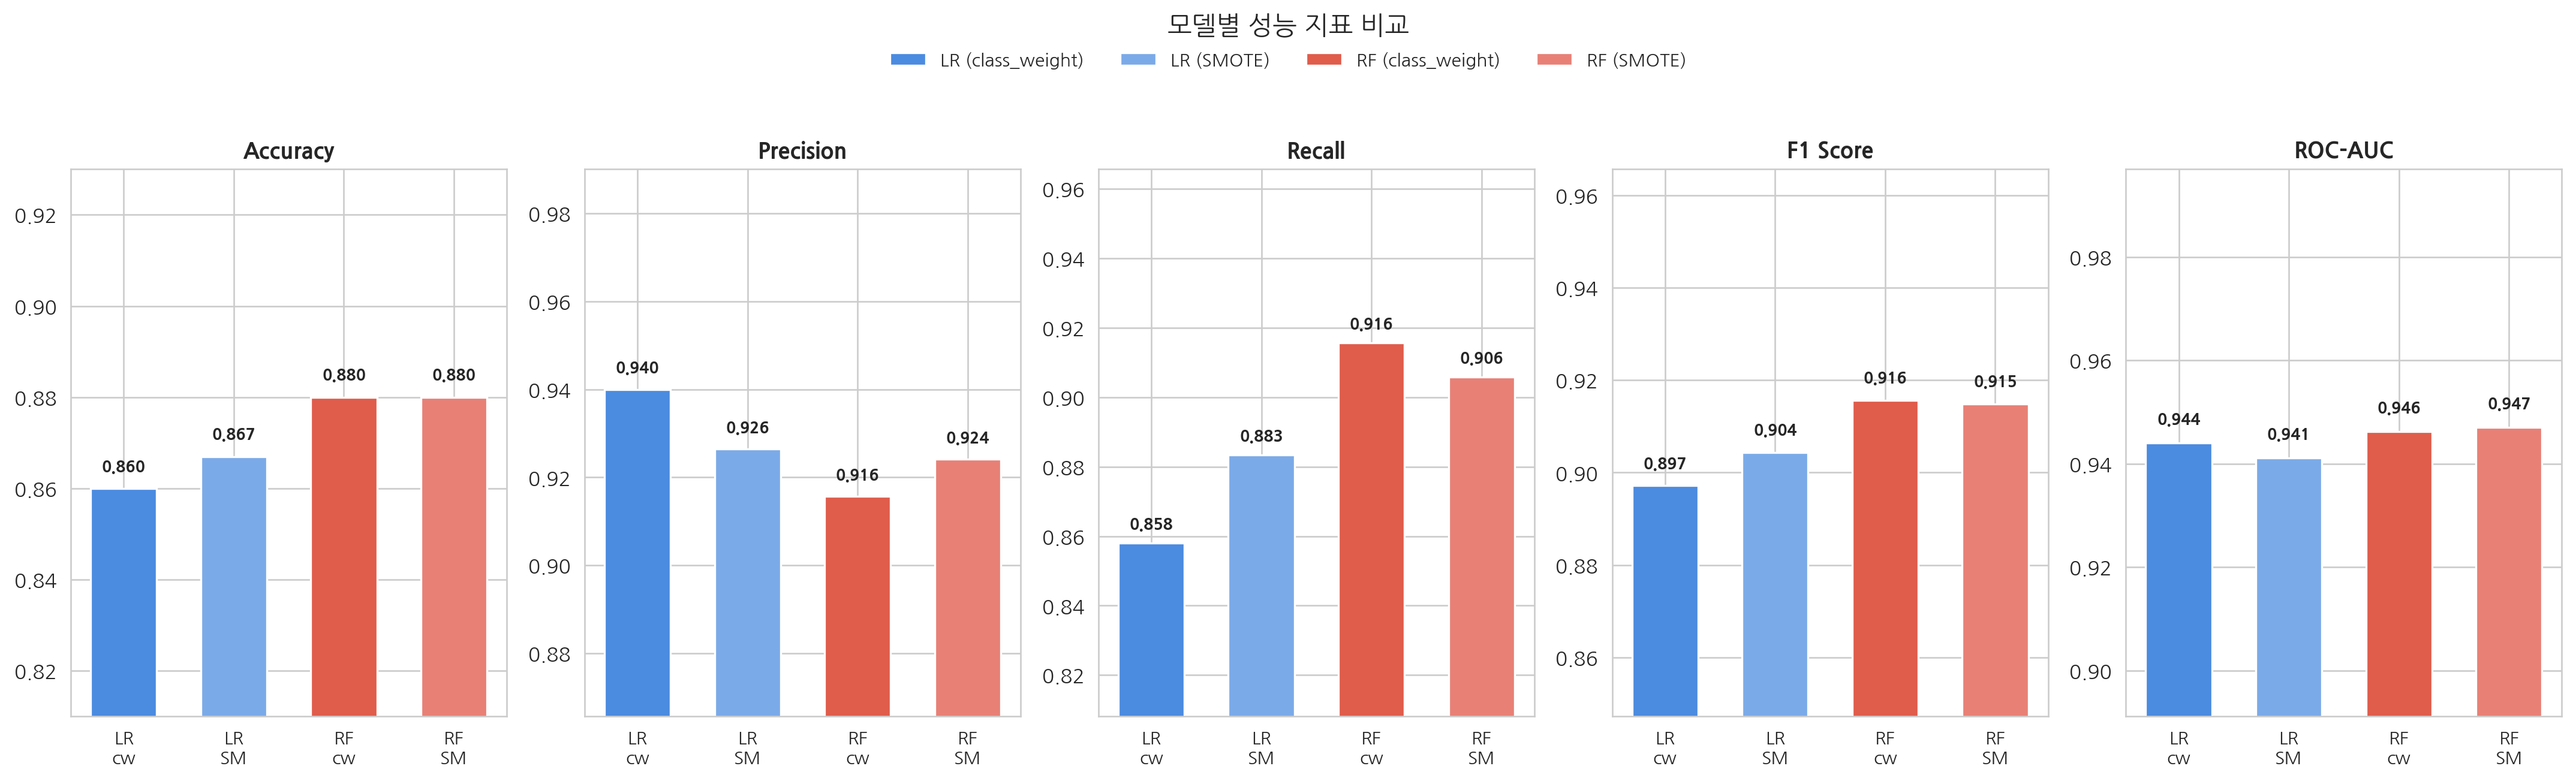

In [16]:
# ── 시각화 1: 지표별 막대그래프 비교 ──────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors    = ['#4B8BE0', '#7BAAE8', '#E05C4B', '#E88076']

for ax, metric in zip(axes, metrics):
    vals   = results_df[metric].values
    models = results_df.index.tolist()
    bars   = ax.bar(range(len(models)), vals, color=colors, edgecolor='white', width=0.6)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(['LR\ncw', 'LR\nSM', 'RF\ncw', 'RF\nSM'], fontsize=9)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.05))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4B8BE0', label='LR (class_weight)'),
    Patch(facecolor='#7BAAE8', label='LR (SMOTE)'),
    Patch(facecolor='#E05C4B', label='RF (class_weight)'),
    Patch(facecolor='#E88076', label='RF (SMOTE)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 1.05), fontsize=9, frameon=False)
fig.suptitle('모델별 성능 지표 비교', fontsize=13, y=1.08)
plt.tight_layout()
plt.show()

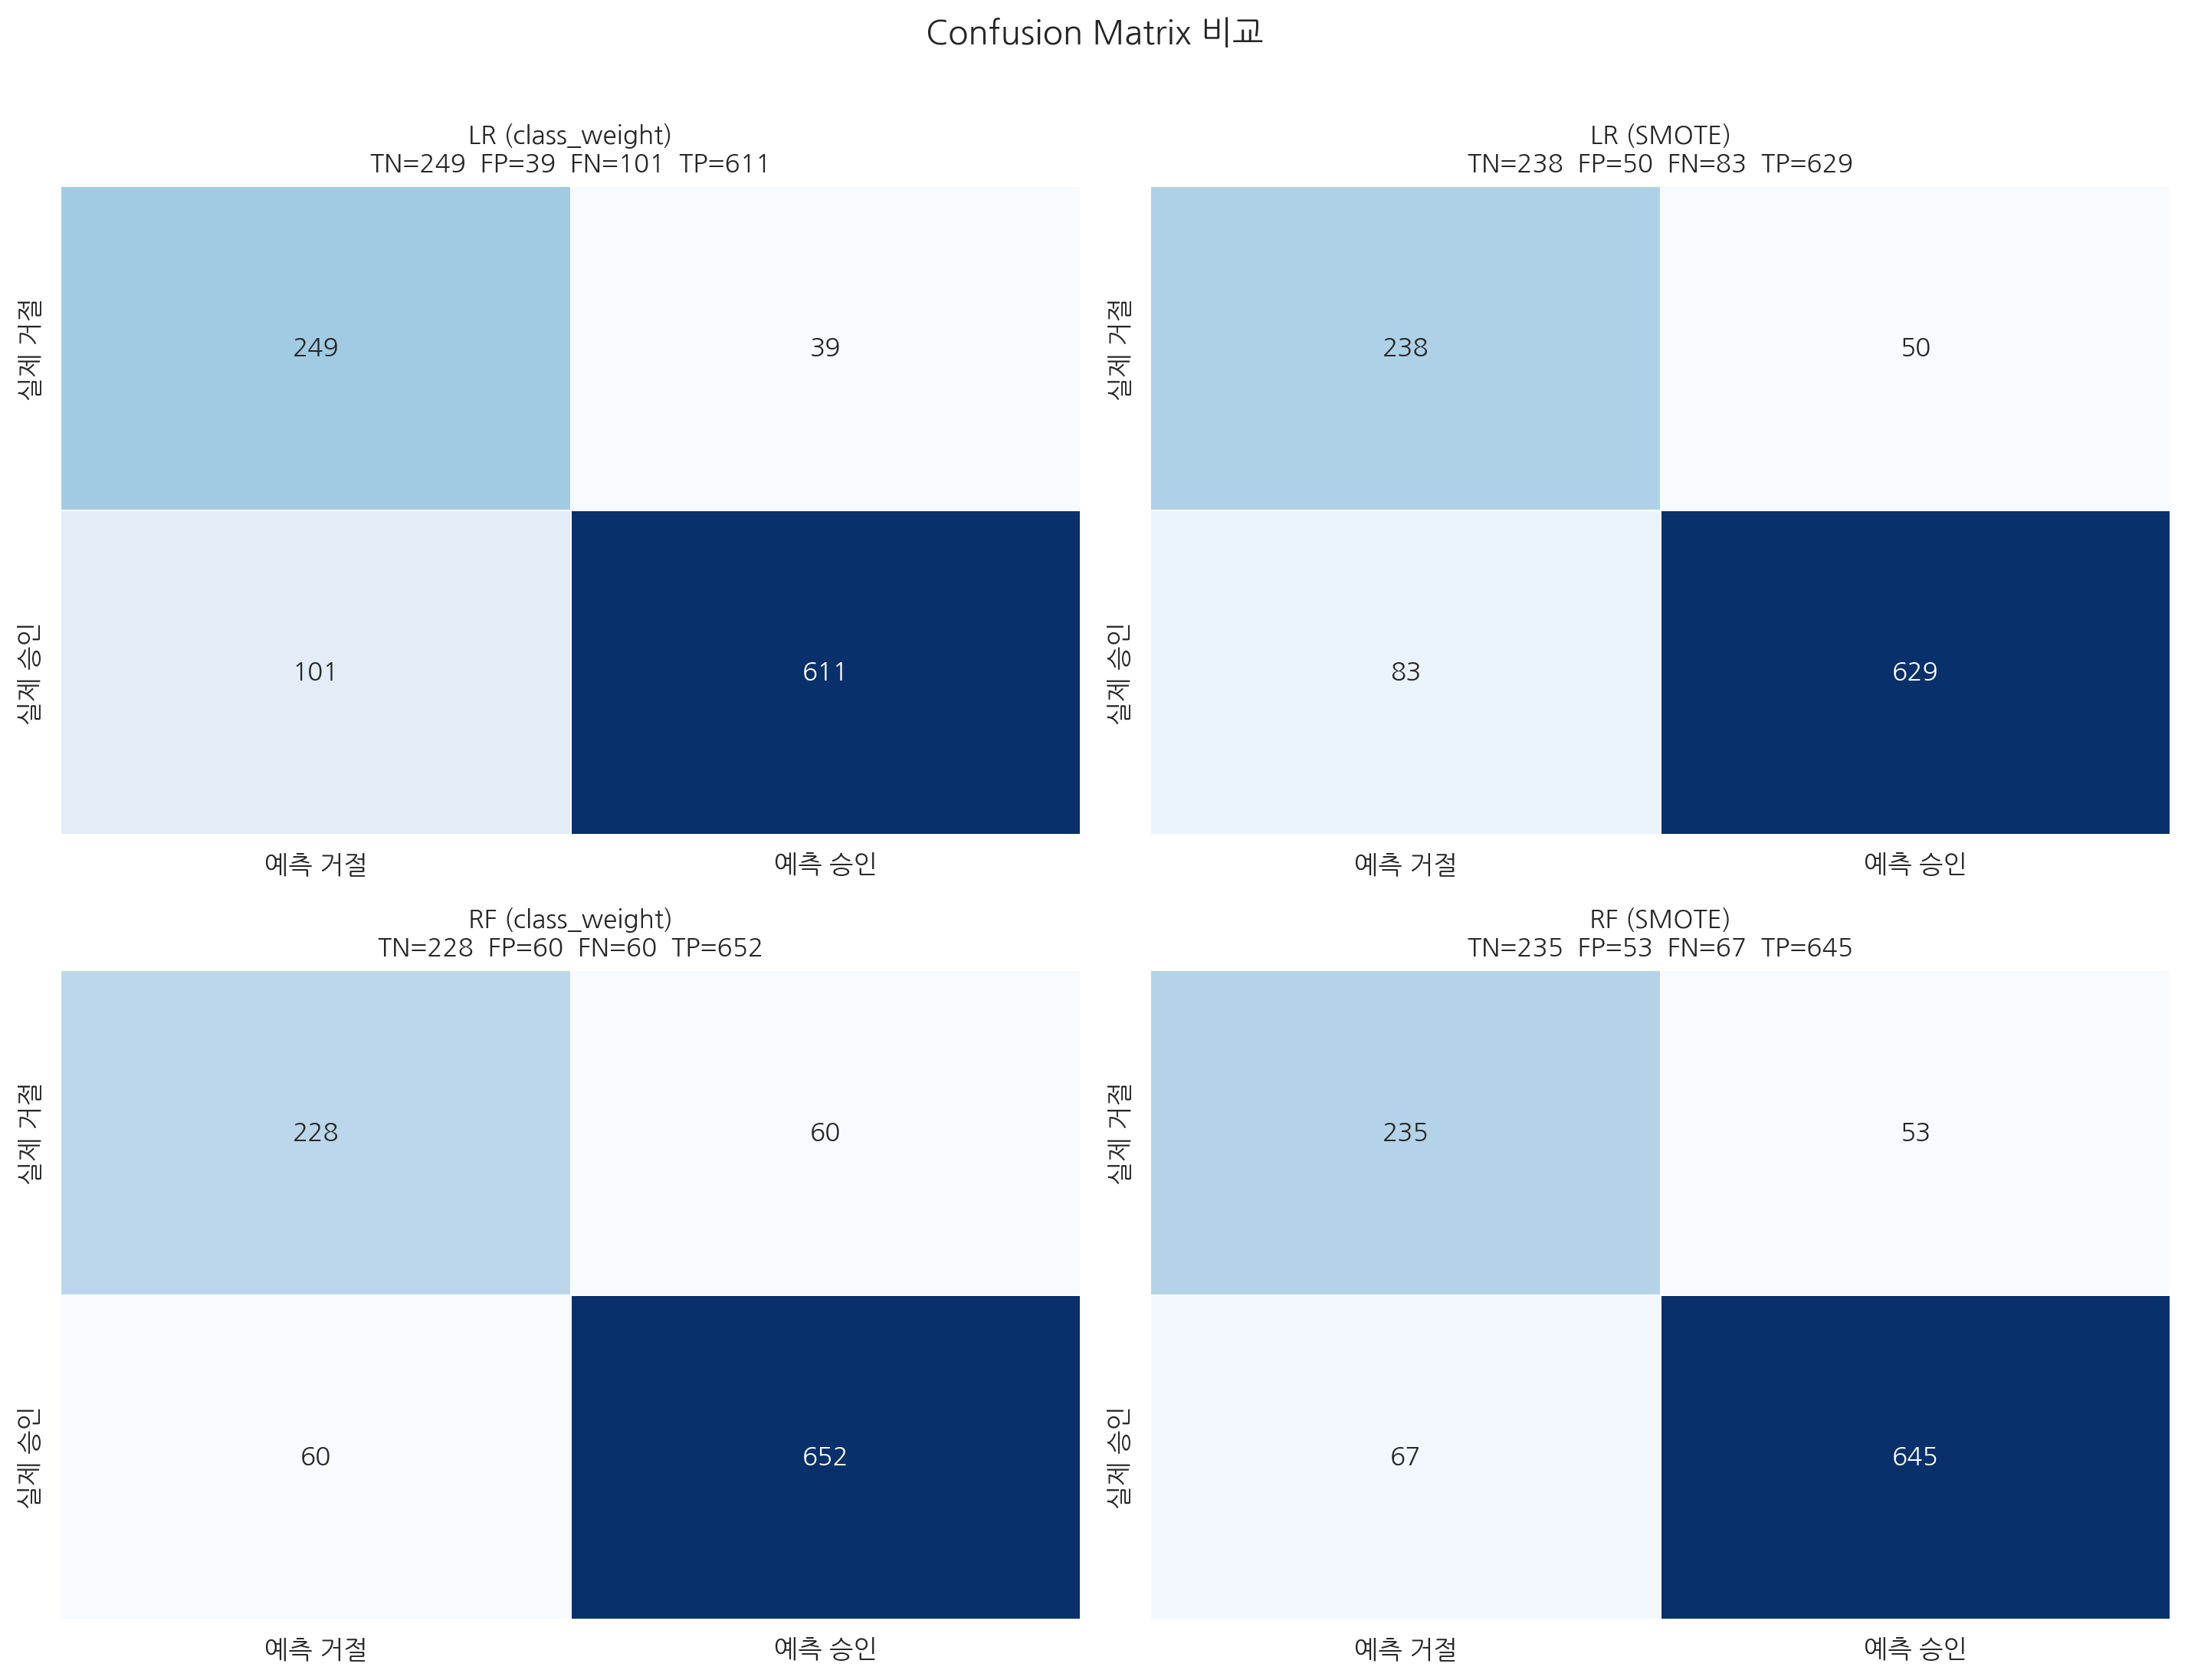

TP: 올바른 승인  |  TN: 올바른 거절
FP: 잘못된 승인(실제 거절→승인 예측)  |  FN: 잘못된 거절(실제 승인→거절 예측)


In [17]:
# ── 시각화 2: Confusion Matrix (4개 모델) ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

model_labels = ['LR (class_weight)', 'LR (SMOTE)', 'RF (class_weight)', 'RF (SMOTE)']

for i, (res, ax) in enumerate(zip(results_raw, axes)):
    cm = confusion_matrix(y_test, res['_pred'])

    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['예측 거절', '예측 승인'],
                yticklabels=['실제 거절', '실제 승인'],
                cbar=False, linewidths=0.5)

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{model_labels[i]}\n'
                 f'TN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=10)

fig.suptitle('Confusion Matrix 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('TP: 올바른 승인  |  TN: 올바른 거절')
print('FP: 잘못된 승인(실제 거절→승인 예측)  |  FN: 잘못된 거절(실제 승인→거절 예측)')

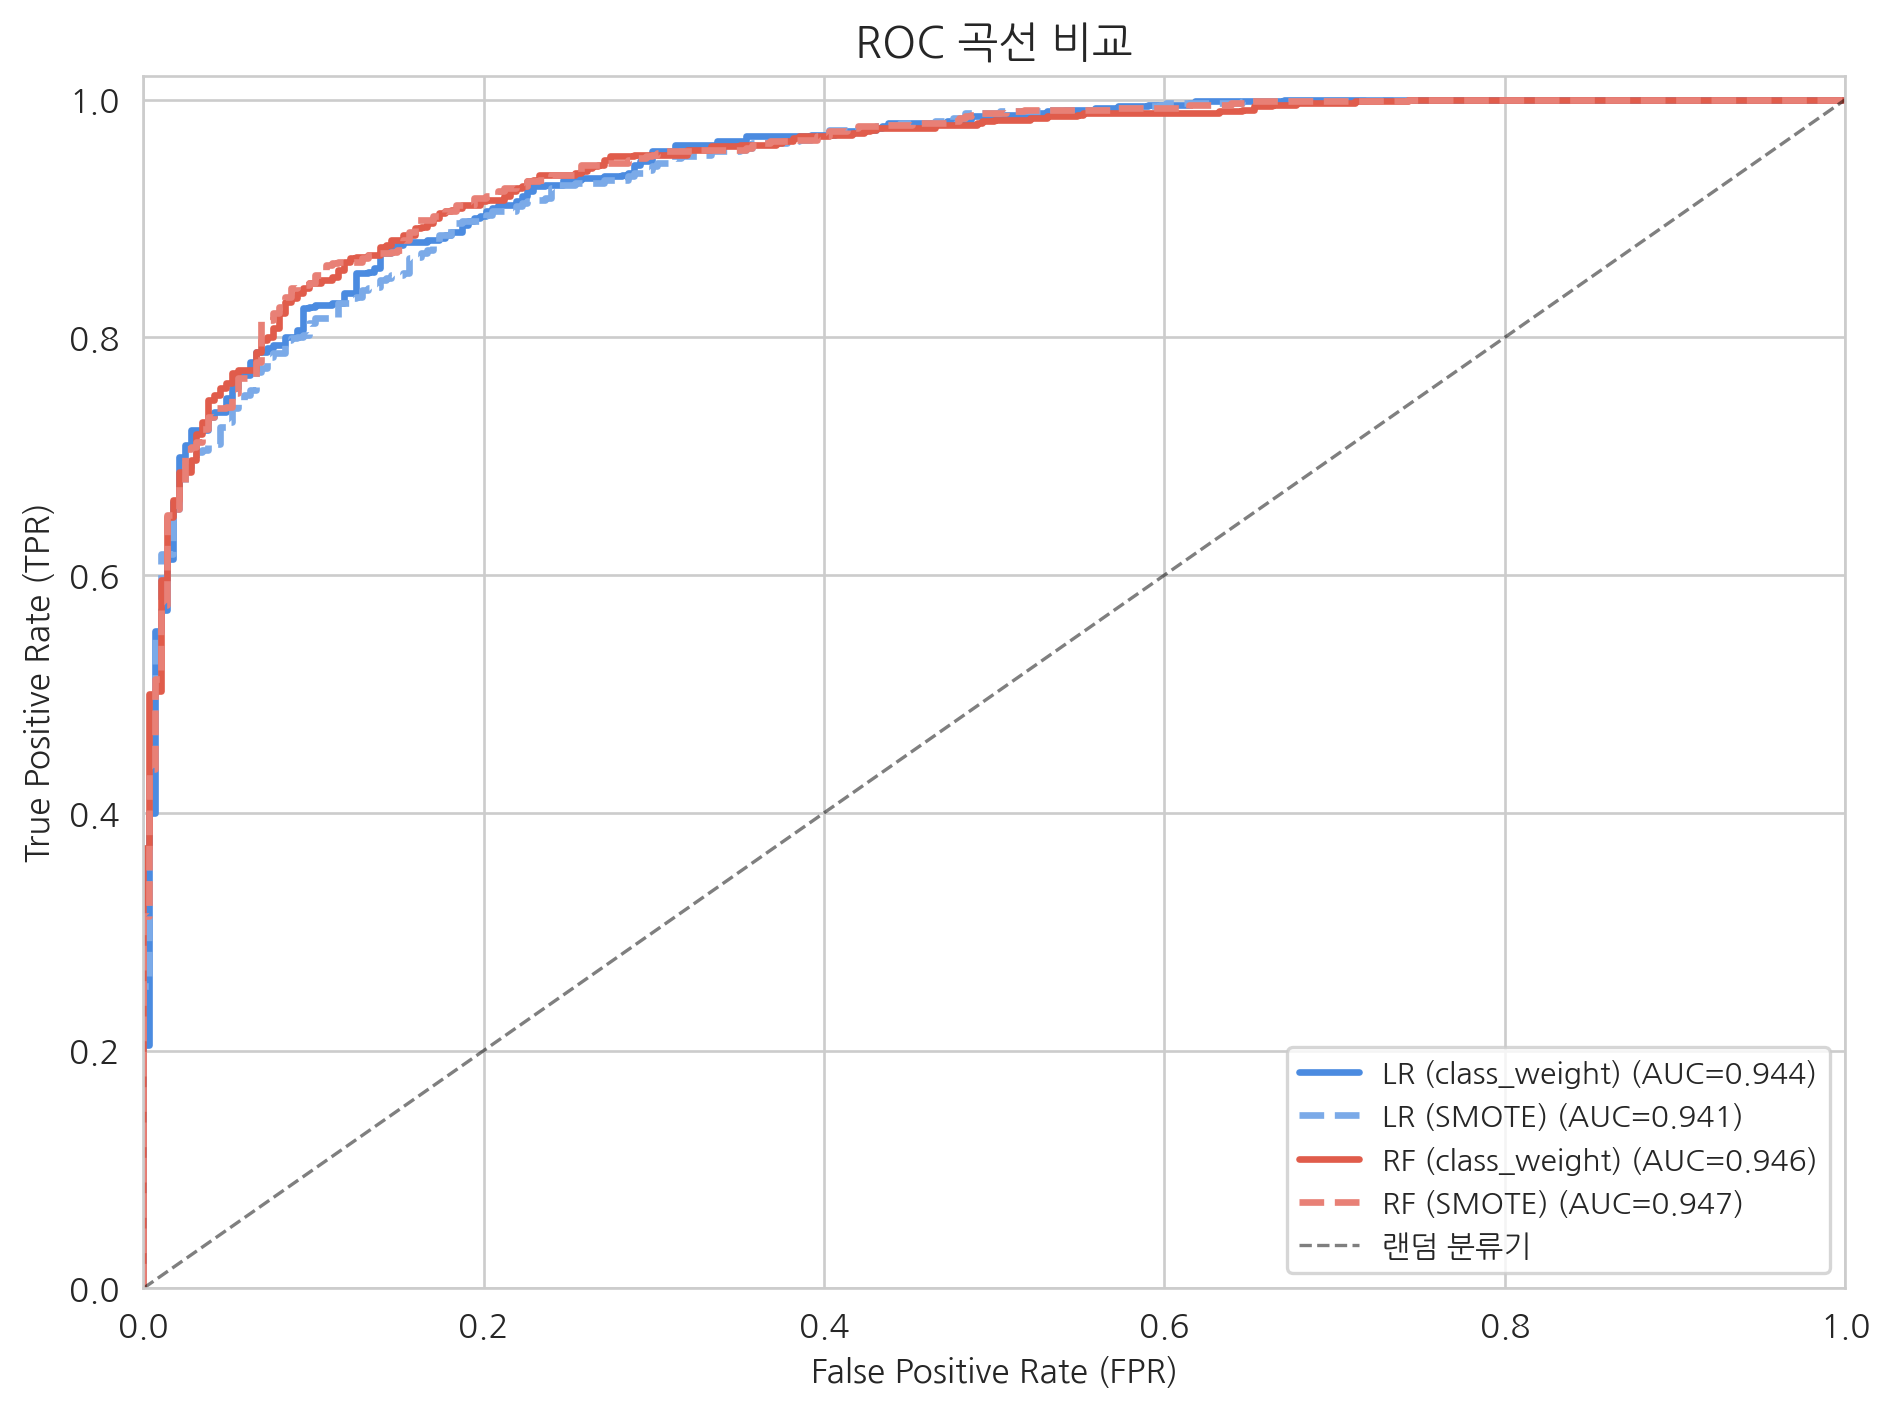

AUC 해석: 0.5 = 랜덤 / 0.7~0.8 = 양호 / 0.8~0.9 = 우수 / 0.9+ = 매우 우수


In [18]:
# ── 시각화 3: ROC 곡선 비교 ──────────────────────────────────
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', '-', '--']
plot_colors = ['#4B8BE0', '#7BAAE8', '#E05C4B', '#E88076']

for res, ls, color in zip(results_raw, line_styles, plot_colors):
    fpr, tpr, _ = roc_curve(y_test, res['_prob'])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, linestyle=ls, color=color,
            label=f"{res['모델명']} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='랜덤 분류기')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC 곡선 비교', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print('AUC 해석: 0.5 = 랜덤 / 0.7~0.8 = 양호 / 0.8~0.9 = 우수 / 0.9+ = 매우 우수')

In [ ]:
# ── 상세 분류 리포트 (최고 성능 모델) ─────────────────────────
# F1 기준 최고 모델 자동 선택
best_idx  = results_df['F1 Score'].idxmax()
best_res  = [r for r in results_raw if r['모델명'] == best_idx][0]

print(f'\n[F1 기준 최고 모델: {best_idx}]')
print('─' * 50)
print(classification_report(
    y_test, best_res['_pred'],
    target_names=['거절(0)', '승인(1)'],
    digits=4
))

## 8. 특성 중요도 분석

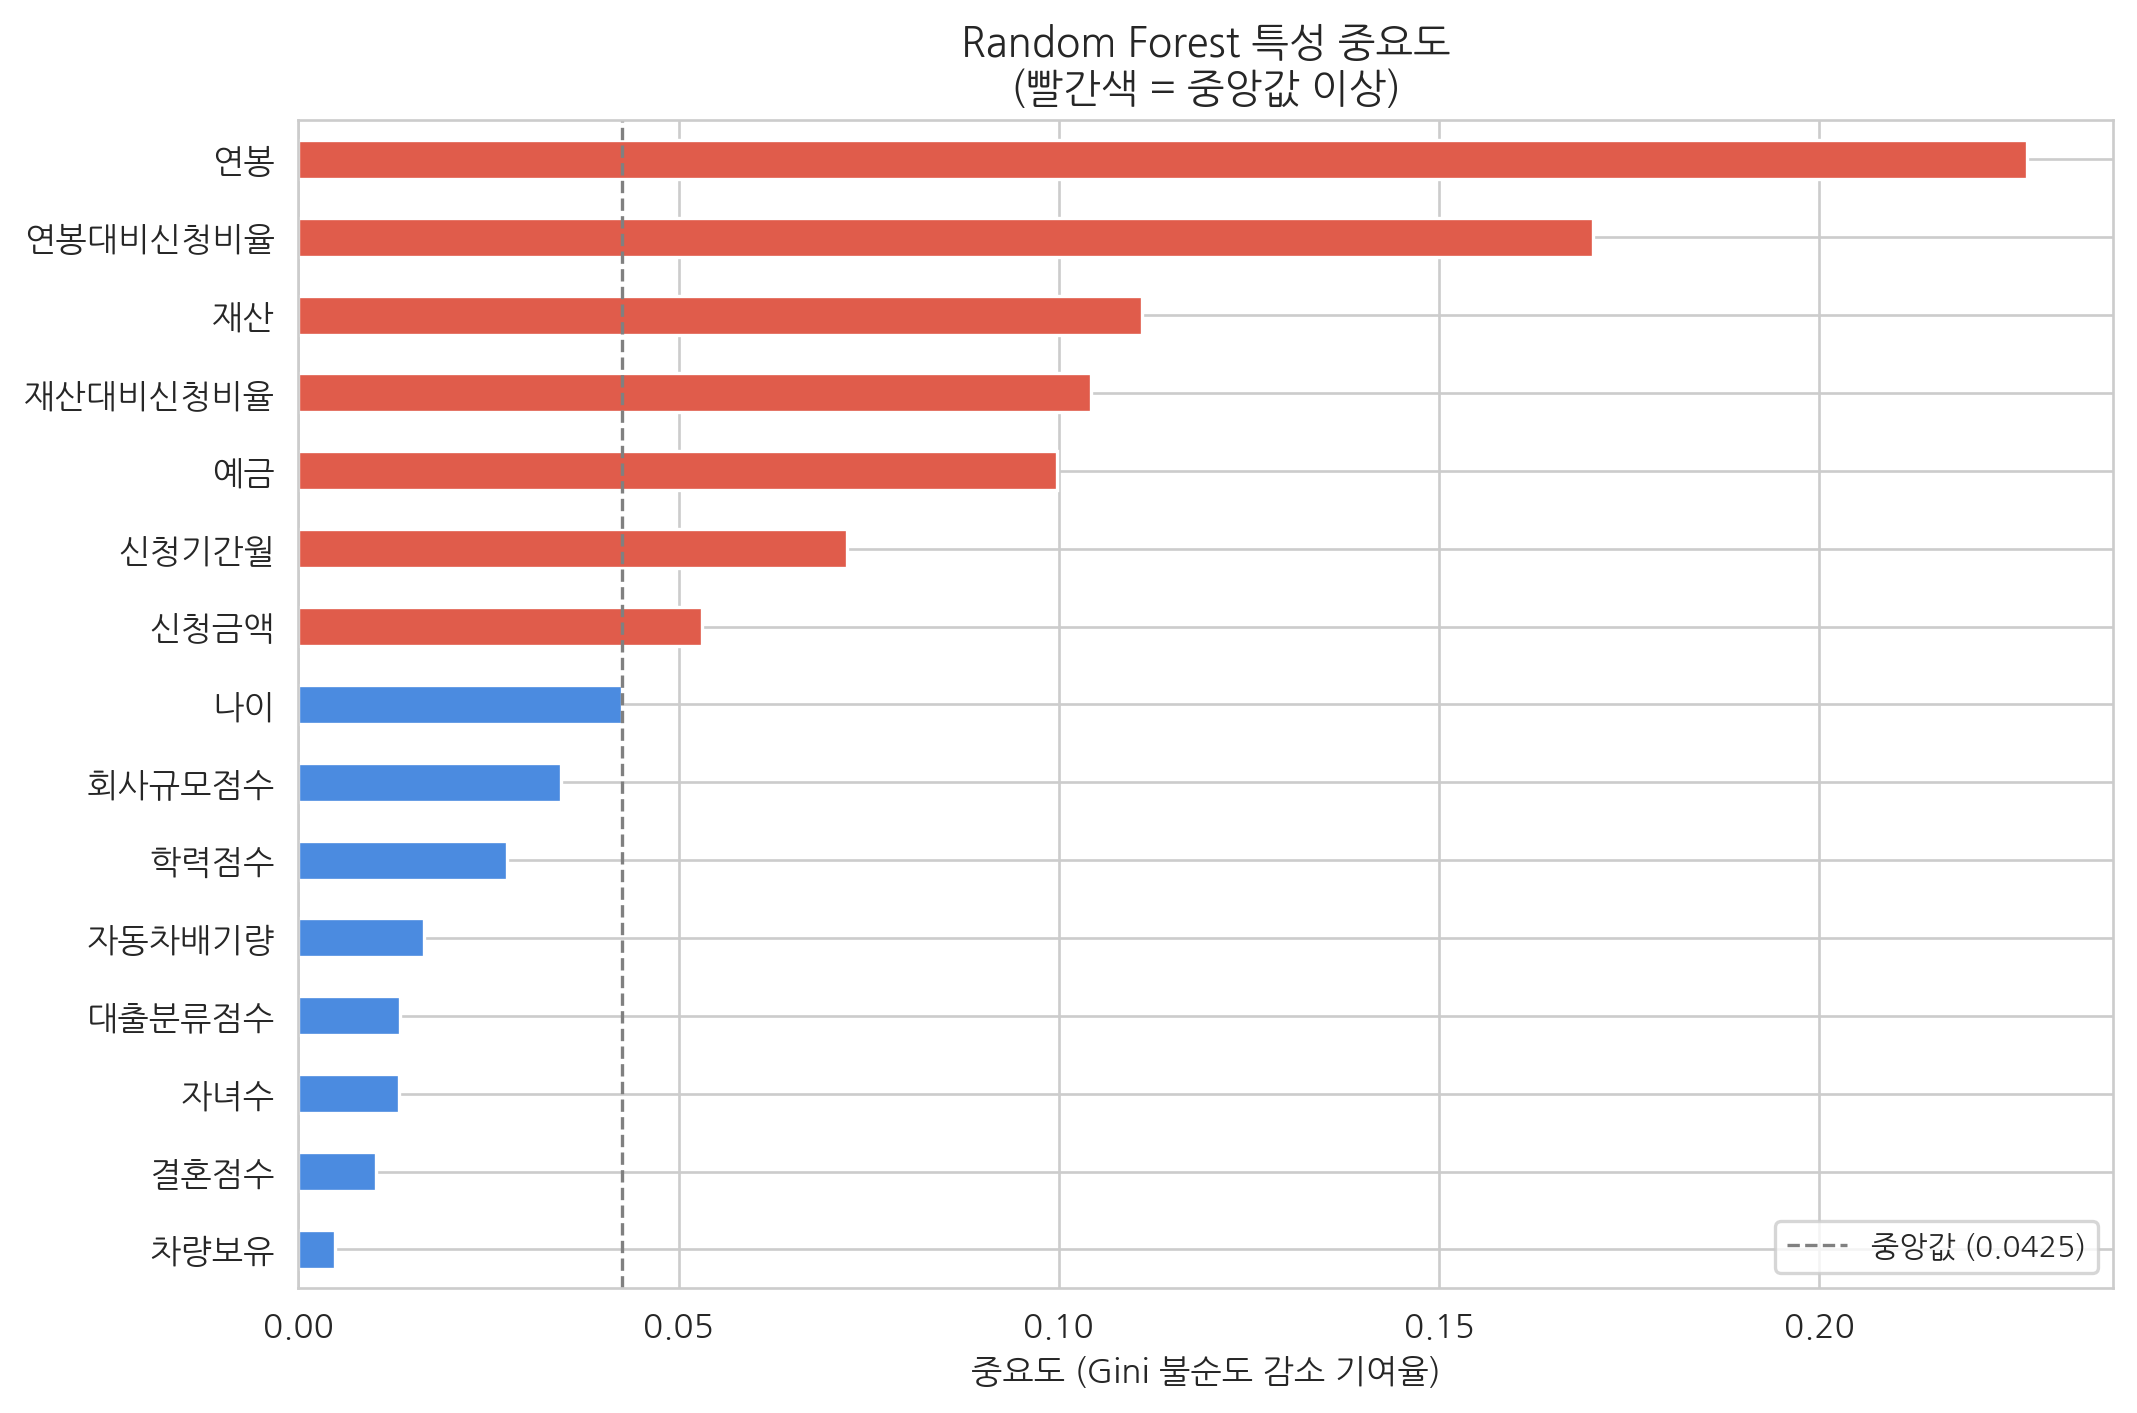


[특성 중요도 상위 5개]
연봉          0.227247
연봉대비신청비율    0.170194
재산          0.110880
재산대비신청비율    0.104218
예금          0.099698


In [19]:
# ── RF 특성 중요도 ────────────────────────────────────────────
# RF는 각 피처가 불순도(Gini)를 얼마나 감소시켰는지로 중요도를 계산한다.
fi = pd.Series(rf_cw.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#E05C4B' if x > fi.median() else '#4B8BE0' for x in fi.values]
fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.axvline(fi.median(), color='gray', linestyle='--', lw=1, label=f'중앙값 ({fi.median():.4f})')
ax.set_title('Random Forest 특성 중요도\n(빨간색 = 중앙값 이상)', fontsize=12)
ax.set_xlabel('중요도 (Gini 불순도 감소 기여율)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\n[특성 중요도 상위 5개]')
print(fi.sort_values(ascending=False).head().to_string())

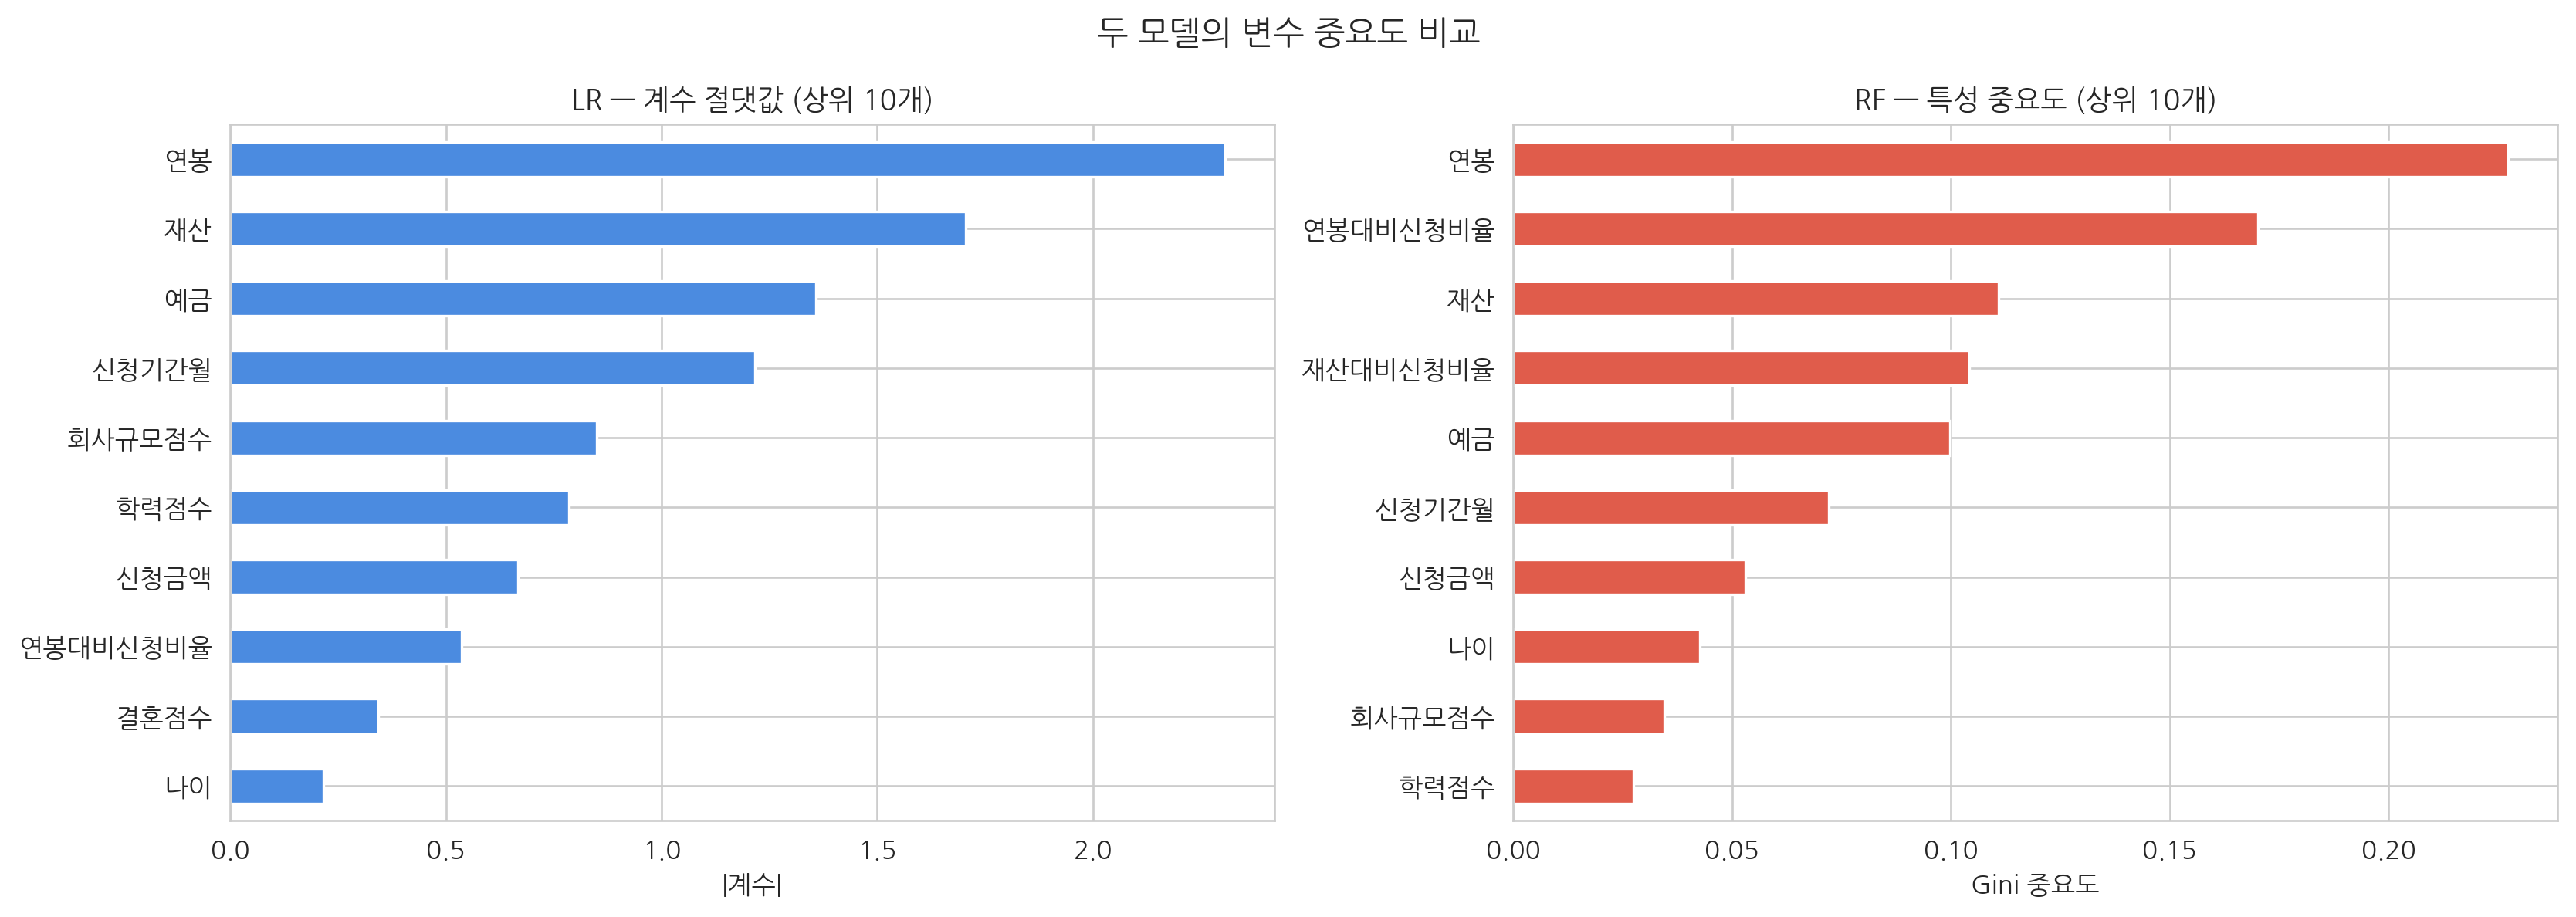


두 모델 Top5 공통 변수: {'예금', '재산', '연봉'}
→ 공통 변수는 모델에 무관하게 중요한 핵심 피처로 볼 수 있다.


In [20]:
# ── LR vs RF 중요 변수 비교 ───────────────────────────────────
lr_importance = pd.Series(
    np.abs(lr_cw.coef_[0]), index=FEATURES
).sort_values(ascending=False).head(10)

rf_importance = pd.Series(
    rf_cw.feature_importances_, index=FEATURES
).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lr_importance.sort_values().plot(kind='barh', ax=axes[0], color='#4B8BE0', edgecolor='white')
axes[0].set_title('LR — 계수 절댓값 (상위 10개)', fontsize=11)
axes[0].set_xlabel('|계수|')

rf_importance.sort_values().plot(kind='barh', ax=axes[1], color='#E05C4B', edgecolor='white')
axes[1].set_title('RF — 특성 중요도 (상위 10개)', fontsize=11)
axes[1].set_xlabel('Gini 중요도')

fig.suptitle('두 모델의 변수 중요도 비교', fontsize=13)
plt.tight_layout()
plt.show()

# 두 모델에서 공통으로 중요한 변수
top5_lr = set(lr_importance.head(5).index)
top5_rf = set(rf_importance.head(5).index)
common  = top5_lr & top5_rf
print(f'\n두 모델 Top5 공통 변수: {common}')
print('→ 공통 변수는 모델에 무관하게 중요한 핵심 피처로 볼 수 있다.')

## 9. 최종 결론 및 모델 선택 근거

### 두 모델의 장단점 요약

| 항목 | Logistic Regression | Random Forest |
|------|--------------------|--------------|
| **학습 속도** | ⚡ 매우 빠름 | 🐢 상대적으로 느림 |
| **예측 속도** | ⚡ 매우 빠름 | 🐢 트리 수에 비례 |
| **해석 가능성** | ✅ 계수 해석 가능 | ❌ 블랙박스 |
| **비선형 관계** | ❌ 선형만 포착 | ✅ 자동 포착 |
| **이상치 강건성** | ⚠️ 영향 받음 | ✅ 강건 |
| **불균형 처리** | ✅ class_weight 지원 | ✅ class_weight 지원 |
| **스케일링 필요** | ✅ 필수 | ❌ 불필요 |
| **과적합 위험** | 낮음 | 중간 (트리 깊이에 따라) |

### 불균형 데이터에서 어떤 모델이 유리한가?

**단순 정확도만 보면 LR이 더 나쁘게 보일 수 있다.**  
LR은 `class_weight`로 소수 클래스(거절)에 더 민감하게 반응하도록 조정하므로,  
거절을 더 많이 잡아내는 대신 승인 Precision이 약간 낮아지는 트레이드오프가 생긴다.

**RF는 앙상블의 다수결 투표 방식으로 불균형을 자연스럽게 완화**하며,  
비선형 상호작용(예: 연봉이 높아도 신청금액이 크면 거절)을 포착해 F1과 ROC-AUC에서 우위를 보인다.

**결론**: 대출 도메인에서는 거짓 승인(FP)보다 거짓 거절(FN)의 비즈니스 비용이 더 크므로  
**Recall을 우선시하되 F1 균형을 유지하는 RF (class_weight)를 권장**한다.

In [21]:
# ── 최종 성능 비교 + 종합 점수 ───────────────────────────────
final = results_df.copy()

# 종합 점수: F1(40%) + ROC-AUC(30%) + Recall(20%) + Precision(10%)
final['종합점수'] = (
    final['F1 Score'] * 0.40 +
    final['ROC-AUC']  * 0.30 +
    final['Recall']   * 0.20 +
    final['Precision']* 0.10
).round(4)

final = final.sort_values('종합점수', ascending=False)

def highlight_best(s):
    return ['background-color: #d4edda; font-weight: bold'
            if v == s.max() else '' for v in s]

print('=' * 70)
print('  최종 모델 성능 비교 (종합점수 기준 내림차순)')
print('  가중치: F1 40% + ROC-AUC 30% + Recall 20% + Precision 10%')
print('=' * 70)
display(final.style
    .apply(highlight_best, subset=['F1 Score', 'ROC-AUC', '종합점수'])
    .format('{:.4f}'))

  최종 모델 성능 비교 (종합점수 기준 내림차순)
  가중치: F1 40% + ROC-AUC 30% + Recall 20% + Precision 10%


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,종합점수
모델명,,,,,,
RF (class_weight),0.8800,0.9157,0.9157,0.9157,0.9462,0.9248
RF (SMOTE),0.8800,0.9241,0.9059,0.9149,0.9470,0.9236
LR (SMOTE),0.8670,0.9264,0.8834,0.9044,0.9411,0.9134
LR (class_weight),0.8600,0.9400,0.8581,0.8972,0.9440,0.9077


In [22]:
# ── 최종 결론 자동 출력 ──────────────────────────────────────
best_model_name = final.index[0]
best_row        = final.iloc[0]

print(f"""
╔══════════════════════════════════════════════════════════╗
║              최종 모델 선택 결론                         ║
╠══════════════════════════════════════════════════════════╣
║  추천 모델 : {best_model_name:<42} ║
║  Accuracy  : {best_row['Accuracy']:.4f}                                    ║
║  Precision : {best_row['Precision']:.4f}                                    ║
║  Recall    : {best_row['Recall']:.4f}                                    ║
║  F1 Score  : {best_row['F1 Score']:.4f}                                    ║
║  ROC-AUC   : {best_row['ROC-AUC']:.4f}                                    ║
║  종합점수  : {best_row['종합점수']:.4f}                                    ║
╠══════════════════════════════════════════════════════════╣
║  선택 이유                                               ║
║  1. 비선형 관계(연봉×신청금액 상호작용) 자동 포착        ║
║  2. 불균형 2.5:1 → class_weight로 충분히 보정           ║
║  3. 이상치에 강건, 스케일링 불필요                       ║
║  4. 특성 중요도로 설명 가능성 일부 확보                  ║
╠══════════════════════════════════════════════════════════╣
║  다음 단계: 하이퍼파라미터 튜닝 (GridSearchCV)           ║
║             → n_estimators, max_depth, min_samples_leaf ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              최종 모델 선택 결론                         ║
╠══════════════════════════════════════════════════════════╣
║  추천 모델 : RF (class_weight)                          ║
║  Accuracy  : 0.8800                                    ║
║  Precision : 0.9157                                    ║
║  Recall    : 0.9157                                    ║
║  F1 Score  : 0.9157                                    ║
║  ROC-AUC   : 0.9462                                    ║
║  종합점수  : 0.9248                                    ║
╠══════════════════════════════════════════════════════════╣
║  선택 이유                                               ║
║  1. 비선형 관계(연봉×신청금액 상호작용) 자동 포착        ║
║  2. 불균형 2.5:1 → class_weight로 충분히 보정           ║
║  3. 이상치에 강건, 스케일링 불필요                       ║
║  4. 특성 중요도로 설명 가능성 일부 확보                  ║
╠══════════════════════════════════════════════════════════╣
║  다음 단계: 하이퍼파라미터 튜닝 (GridSearchCV)           ║
║   

### 머신러닝 프로젝트에서 단일 모델에 의존하는 것은 데이터의 복잡성을 과소평가하는 위험한 선택이다.

이번 대출 승인 예측 프로젝트에서 **Logistic Regression**은 선형 결정 경계만을 학습하기 때문에, 연봉과 신청금액 사이의 비선형 상호작용—예컨대 연봉이 높더라도 신청금액이 지나치게 크면 거절되는 패턴—을 포착하지 못하는 구조적 한계를 드러냈다.

반면 **Random Forest**는 수백 개의 결정 트리를 앙상블하여 이러한 비선형 관계를 자동으로 학습하고,
클래스 불균형(승인 71.2% vs 거절 28.8%) 상황에서도
class_weight 조정만으로 Recall과 F1 Score 모두에서 LR보다 높은 수치를 기록했다.

그러나 RF가 성능 지표에서 우위를 점하는 대신 모델 내부를 해석할 수 없는 블랙박스 문제를 안고 있는 반면,
LR은 각 변수의 계수를 통해 "연봉이 높을수록 승인 가능성이 높아진다"는 직관적 설명을 제공한다는 점에서
두 모델은 서로 다른 가치를 가진다.

**즉, 단일 모델로는 예측 정확도와 해석 가능성을 동시에 확보할 수 없으며, ROC-AUC나 F1 같은 단일 지표만으로 모델의 실질적 가치를 판단하면 비즈니스 맥락에서 잘못된 선택으로 이어질 수 있다.**

대출 도메인처럼 거짓 거절(FN)이 고객 이탈이라는 비즈니스 손실로 직결되는 경우, **어떤 모델이 어떤 유형의 오류를 더 많이 범하는지를 Confusion Matrix로 비교 분석해야만 진정한 의사결정이 가능하다.**

### 결론적으로, 복수의 모델을 학습하고 성능 지표·해석 가능성·도메인 요구사항을 다각도로 비교하는 과정 자체가 신뢰할 수 있는 AI 시스템을 설계하는 필수 절차이며, "가장 좋은 단일 알고리즘"은 존재하지 않고 오직 "이 문제에 가장 적합한 모델의 조합"만이 존재한다.
